# Commonsense MCQA

Multiple choice question answering is a common format for evaluating a model's reasoning ability. This notebook studies how few-shot prompting compares to a LoRA adapter (trained with DPO) on the [CommonsenseQA](https://huggingface.co/datasets/tau/commonsense_qa) dataset, with the unsteered model as a reference. We sweep over the number of (positive) few-shot examples and study accuracy and positional bias under deterministic choice shuffling, across two models.

### Runtime estimate

> **Estimated time:** ~60-90 minutes (training a LoRA adapter per model and running the few-shot sweep across trials)  
> **Device:** NVIDIA H100 GPU (80GB VRAM)

Times are approximate and vary with the number of questions, shuffling runs, sweep points, and trials.

## Setup

In [1]:
import importlib.util
from pathlib import Path

import pandas as pd
import transformers
from datasets import Dataset, load_dataset
from matplotlib import gridspec
from matplotlib import pyplot as plt

from steerability.algorithms.core.specs import ControlSpec
from steerability.algorithms.input_control.few_shot.control import FewShot
from steerability.algorithms.structural_control.wrappers.trl.dpotrainer.control import DPO
from steerability.evaluation.plotting import apply_plot_style, plot_sensitivity, plot_tradeoff
from steerability.evaluation.provider import ProviderOptions
from steerability.evaluation.runner import SteeringEval, summarize_runs
from steerability.evaluation.suite import InspectSuite
from steerability.utils.verbosity import quiet_third_party

quiet_third_party()

_cwd = Path.cwd()
NOTEBOOK_DIR = _cwd if _cwd.name == "commonsense_mcqa" else _cwd / "examples/notebooks/studies/commonsense_mcqa"
NOTEBOOK_DIR = NOTEBOOK_DIR.resolve()

## Defining the evaluation task

The evaluation task lives in `task.py` next to this notebook, which `InspectSuite` runs through the reference `task.py@commonsense_mcqa`.

In that file, `multiple_choice()` formats and generates, `choice()` parses and scores, and the `accuracy()` and `stderr()` metrics are joined by a custom `positional_bias()` metric. Each validation question is expanded into `num_shuffling_runs` samples (one per deterministic shuffle of its answer choices) so accuracy and positional bias are measured over repeated presentations of the same question.

In [2]:
TASK_FILE = NOTEBOOK_DIR / "task.py"
TASK_REFERENCE = f"{TASK_FILE}@commonsense_mcqa"

_task_spec = importlib.util.spec_from_file_location("task", TASK_FILE)
_task_module = importlib.util.module_from_spec(_task_spec)
_task_spec.loader.exec_module(_task_module)
LETTERS = _task_module.LETTERS
CSQA_PATH = _task_module.CSQA_PATH
format_example = _task_module.format_example

The configuration below sets the models, the few-shot sweep points, the evaluation size, and the DPO hyperparameters.

The DPO preference pairs differ only in the final answer letter, so the plain sigmoid loss can lower the probability of both completions while still widening their log-ratio, which pushes the model off the `ANSWER: <letter>` format (likelihood displacement). `DPO_SFT_WEIGHT` weights a negative log-likelihood term on the chosen completion (TRL's `sft` loss) that anchors it, and `DPO_BETA` sets how far the log-ratio can move before the sigmoid loss saturates. `DPO_HPARAMS` holds the per-model learning rate and epoch count.

In [3]:
MODELS = [
    "Qwen/Qwen2.5-0.5B-Instruct",
    "Qwen/Qwen2.5-1.5B-Instruct",
]
KS = [1, 5, 10, 25, 50, 100]
NUM_QUESTIONS = 50
NUM_SHUFFLING_RUNS = 20
NUM_TRIALS = 5
SEED = 7
POOL_SIZE = 2000
SKIP_DPO = False
SAVE_DIR = NOTEBOOK_DIR / "runs" / "commonsense_mcqa"

TEMPERATURE = 0.7
MAX_TOKENS = 32
SHUFFLE_SEED = 0

METRICS = {"accuracy": "choice/accuracy", "positional_bias": "choice/positional_bias"}
SWEPT_PARAMS = {"k_positive": ("FewShot", "k_positive")}
DPO_SFT_WEIGHT = 1.0  # weight of TRL's sft loss on the chosen completion
DPO_BETA = 0.5
DPO_DEFAULT_HPARAMS = {"learning_rate": 1e-5, "num_train_epochs": 1}
DPO_HPARAMS = {
    "Qwen2.5-0.5B-Instruct": {"learning_rate": 1e-5, "num_train_epochs": 1},
    "Qwen2.5-1.5B-Instruct": {"learning_rate": 1e-5, "num_train_epochs": 1},
}

## Loading the data

The evaluation split is loaded inside the task from the `validation` split of [CommonsenseQA](https://huggingface.co/datasets/tau/commonsense_qa). Here we load the `train` split, which supplies the steering data (few-shot example pools and DPO preference pairs).

In [4]:
records = load_dataset(CSQA_PATH, split="train")
records

Dataset({
    features: ['id', 'question', 'question_concept', 'choices', 'answerKey'],
    num_rows: 9741
})

## Preparing the steering data

Both steering methods draw from the `train` split and render prompts with the task's `format_example`, so the exemplars and training prompts match the evaluation-time prompt, with completions in the `ANSWER: <letter>` form the `choice()` scorer parses. The function below builds the few-shot pools and the DPO preference pairs from the same records. Each valid record contributes one positive exemplar (the correct answer), one negative exemplar (a wrong answer), and up to four preference pairs (the correct letter against each wrong letter). Records without a single-letter in-range answer key are skipped.

The pools are capped at `POOL_SIZE` because they enter the few-shot sweep's `ControlSpec.params`, and the values in `params` are part of the configuration identity used for checkpointing. The preference data is not capped, since a fixed control's dataset argument does not enter the configuration identity.

In [5]:
def build_steering_data(records, pool_size: int) -> tuple[list[dict], list[dict], Dataset]:
    positive_pool: list[dict] = []
    negative_pool: list[dict] = []
    preference_rows: list[dict] = []
    for record in records:
        choices = list(record["choices"]["text"])
        answer_key = record["answerKey"]
        if len(answer_key) != 1 or answer_key not in LETTERS[: len(choices)]:
            continue
        prompt = format_example(record["question"], choices)
        correct = f"ANSWER: {answer_key}"
        wrong_letters = [letter for letter in LETTERS[: len(choices)] if letter != answer_key]
        positive_pool.append({"prompt": prompt, "response": correct})
        negative_pool.append({"prompt": prompt, "response": f"ANSWER: {wrong_letters[0]}"})
        for wrong in wrong_letters[:4]:
            preference_rows.append({"prompt": prompt, "chosen": correct, "rejected": f"ANSWER: {wrong}"})
    if pool_size:
        positive_pool = positive_pool[:pool_size]
        negative_pool = negative_pool[:pool_size]
    return positive_pool, negative_pool, Dataset.from_list(preference_rows)

In [6]:
positive_pool, negative_pool, preference_data = build_steering_data(records, POOL_SIZE)
print(f"pools: {len(positive_pool)} positive / {len(negative_pool)} negative")
print(f"preference pairs: {len(preference_data)}")

pools: 2000 positive / 2000 negative
preference pairs: 38964


### Few-shot example pools

The `FewShotBlockFormatter` renders each non-underscore key of a pool entry as a `Title-Cased Key: value` line under the polarity header, so the `{"prompt": ..., "response": ...}` entries render as `Prompt: ...` and `Response: ...`. The prompt is the full evaluation-time prompt and the response is the `ANSWER: <letter>` completion.

In [7]:
positive_pool[0]

{'prompt': "Answer the following multiple choice question. The entire content of your response should be of the following format: 'ANSWER: $LETTER' (without quotes) where LETTER is one of A,B,C,D,E.\n\nThe sanctions against the school were a punishing blow, and they seemed to what the efforts the school had made to change?\n\nA) ignore\nB) enforce\nC) authoritarian\nD) yell at\nE) avoid",
 'response': 'ANSWER: A'}

### DPO preference pairs

The preference pairs share the same prompt format. Each pair contrasts the correct letter against one wrong letter, so a question with five choices yields up to four pairs.

In [8]:
preference_data[0]

{'prompt': "Answer the following multiple choice question. The entire content of your response should be of the following format: 'ANSWER: $LETTER' (without quotes) where LETTER is one of A,B,C,D,E.\n\nThe sanctions against the school were a punishing blow, and they seemed to what the efforts the school had made to change?\n\nA) ignore\nB) enforce\nC) authoritarian\nD) yell at\nE) avoid",
 'chosen': 'ANSWER: A',
 'rejected': 'ANSWER: B'}

## Defining the controls

One goal of the study is to see how the number of in-context examples affects behavior. We use `ControlSpec` to sweep `k_positive` for the `FewShot` control, fixing `k_negative=0` to isolate the effect of positive examples (pinned in the `params` block of the spec). The spec is named `FewShot`, which is the key `runtime_overrides` and the swept-parameter attachment use later.

In [9]:
few_shot = ControlSpec(
    control_cls=FewShot,
    params={
        "selector": "random",
        "positive_example_pool": positive_pool,
        "negative_example_pool": negative_pool,
        "k_negative": 0,
    },
    vars=[{"k_positive": k} for k in KS],
    name="FewShot",
)

### DPO with LoRA

The DPO-LoRA control fine-tunes a LoRA adapter on the preference pairs. The two models train with slightly different hyperparameters, so the function below builds the control per model, reading the learning rate and epoch count from `DPO_HPARAMS`. The `peft_type` argument defaults to LoRA, so it does not need to be passed.

Note that `prompt_format="chat_prompt"` renders each training prompt through the model's chat template, so the prompt the adapter trains on matches what the evaluation sends at inference (the eval always templates). Without it, training and evaluation see different prompt formats.

We combine the sigmoid loss with TRL's `sft` loss, a negative log-likelihood term on the chosen completion weighted by `DPO_SFT_WEIGHT`, so the adapter keeps producing the answer format while learning the preference. The `beta` argument sets how far the chosen-to-rejected log-ratio can move before the sigmoid loss saturates. The default `beta=0.1` allows a large move, which for pairs that differ by a single token comes mostly from distorting the distribution at that position, so we set `DPO_BETA=0.5` to saturate sooner. TRL's training log reports two quantities worth watching. When the anchor is working, `rewards/chosen` stays near zero and `mean_token_accuracy` rises toward one. A run where `rewards/chosen` drifts strongly negative while `mean_token_accuracy` falls is displacing likelihood.

In [10]:
def build_dpo_control(model_name: str, model_dir: Path) -> DPO:
    short_name = model_name.split("/")[-1]
    hparams = DPO_HPARAMS.get(short_name, DPO_DEFAULT_HPARAMS)
    return DPO(
        train_dataset=preference_data,
        output_dir=str(model_dir / "dpo"),
        prompt_format="chat_prompt",
        loss_type=["sigmoid", "sft"],
        loss_weights=[1.0, DPO_SFT_WEIGHT],
        beta=DPO_BETA,
        per_device_train_batch_size=8,
        gradient_accumulation_steps=2,
        max_length=512,
        disable_dropout=True,
        logging_steps=100,
        save_strategy="no",
        report_to="none",
        seed=123,
        use_peft=True,
        r=16,
        lora_alpha=32,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
        **hparams,
    )

## Running the evaluation

For each model we evaluate three arms: the unsteered baseline, the few-shot sweep, and (unless `SKIP_DPO`) the DPO-LoRA adapter. `SteeringEval` builds and steers each configuration once, then runs `NUM_TRIALS` trials against the `commonsense_mcqa` task. Sampling is enabled through `temperature > 0` so trials vary, and the base seed keeps each (configuration, trial) reproducible. Seeded sampling decodes in batches of 8 under the provider's default `seed_scope="dispatch"`, and trial-to-trial variation is measured over `NUM_TRIALS`. The per-model per-trial frame is written to `runs.csv` so the figures can be rebuilt after a kernel restart, alongside Inspect's own log-level resume. Note that `eval_set` resumes completed cells from the logs under `SAVE_DIR`, so we use a new `SAVE_DIR` when the protocol changes (the seed, generation defaults, provider options, or task).

Two settings control how much the run prints. `display` is Inspect's per-sample progress mode: `"none"` (used here) leaves the tqdm bar over (configuration, trial, suite) cells as the only progress signal, while `"plain"` streams per-sample accuracy. `logging_steps` (set on the DPO control) governs how often TRL prints its training statistics. Note that the DPO arm's `rewards/chosen` and `mean_token_accuracy` lines are the training health check described above.

In [11]:
def run_model(model_name: str) -> pd.DataFrame:
    short_name = model_name.split("/")[-1]
    model_dir = SAVE_DIR / short_name
    model_dir.mkdir(parents=True, exist_ok=True)

    pipelines: dict[str, list] = {"baseline": [], "few_shot_sweep": [few_shot]}
    if not SKIP_DPO:
        pipelines["dpo_lora"] = [build_dpo_control(model_name, model_dir)]

    runner = SteeringEval(
        pipelines=pipelines,
        base_model_name_or_path=model_name,
        suites=[InspectSuite(
            name="mcqa",
            tasks=(TASK_REFERENCE,),
            task_args={
                "num_questions": NUM_QUESTIONS,
                "num_shuffling_runs": NUM_SHUFFLING_RUNS,
                "shuffle_seed": SHUFFLE_SEED,
            },
        )],
        num_trials=NUM_TRIALS,
        seed=SEED,
        generate_defaults={"temperature": TEMPERATURE, "max_tokens": MAX_TOKENS},
        provider_options=ProviderOptions(max_batch_size=8),
        save_dir=model_dir,
        display="none",
    )
    runner.run()

    runs = runner.runs_frame(METRICS, params=SWEPT_PARAMS)
    runs.insert(0, "model", short_name)
    runs.to_csv(model_dir / "runs.csv", index=False)
    return runs

In [12]:
frames = []
model_order = []
for model_name in MODELS:
    print(f"evaluating {model_name}")
    frames.append(run_model(model_name))
    model_order.append(model_name.split("/")[-1])

runs = pd.concat(frames, ignore_index=True)

evaluating Qwen/Qwen2.5-0.5B-Instruct


steering eval:   0%|          | 0/40 [00:00<?, ?cell/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Completed all tasks in 
'/dccstor/principled_ai/users/erikmiehling/AISteer360/examples/notebooks/studies/commonsense_mcqa/runs/commonsense_
mcqa/Qwen2.5-0.5B-Instruct/inspect_logs/baseline/trial_0/mcqa' successfully

Completed all tasks in 
'/dccstor/principled_ai/users/erikmiehling/AISteer360/examples/notebooks/studies/commonsense_mcqa/runs/commonsense_
mcqa/Qwen2.5-0.5B-Instruct/inspect_logs/baseline/trial_1/mcqa' successfully

...

Output()

Output()

Output()

Output()

Output()

## Analysis

We analyze the results across both models. The per-trial frame contains one row per (pipeline, trial) with the requested metrics and the swept `k_positive` value. The baseline and DPO rows contain `NaN` for `k_positive`.

In [13]:
runs[["model", "pipeline", "trial_id", "k_positive", "accuracy", "positional_bias"]]

,model,pipeline,trial_id,k_positive,accuracy,positional_bias
0,Qwen2.5-0.5B-Instruct,baseline,0,NaN,0.457,0.290542
1,Qwen2.5-0.5B-Instruct,baseline,1,NaN,0.459,0.315850
2,Qwen2.5-0.5B-Instruct,baseline,2,NaN,0.458,0.329029
3,Qwen2.5-0.5B-Instruct,baseline,3,NaN,0.479,0.281799
4,Qwen2.5-0.5B-Instruct,baseline,4,NaN,0.478,0.315142
...,...,...,...,...,...,...
75,Qwen2.5-1.5B-Instruct,few_shot_sweep,0,5.0,0.740,0.237000
76,Qwen2.5-1.5B-Instruct,few_shot_sweep,1,5.0,0.727,0.240000
77,Qwen2.5-1.5B-Instruct,few_shot_sweep,2,5.0,0.728,0.251000
78,Qwen2.5-1.5B-Instruct,few_shot_sweep,3,5.0,0.734,0.249842


We aggregate the trials into a summary frame with `summarize_runs`, grouping by model, pipeline, and configuration and carrying the swept `k_positive` value through. Each metric gains `_mean`, `_std`, and `_sem` columns. We also apply the shared plot style here so the figures below match the toolkit's scientific style.

In [14]:
apply_plot_style()

summary = summarize_runs(
    runs,
    ["accuracy", "positional_bias"],
    group_cols=["model", "pipeline", "config_id"],
    param_cols=["k_positive"],
)


def arm(model: str, pipeline: str) -> pd.DataFrame:
    return summary[(summary["model"] == model) & (summary["pipeline"] == pipeline)]


def refs_for(model: str) -> list[tuple[str, pd.DataFrame]]:
    references = [("baseline", arm(model, "baseline"))]
    dpo = arm(model, "dpo_lora")
    if not dpo.empty:
        references.append(("DPO-LoRA", dpo))
    return references

summary[["model", "pipeline", "k_positive", "n_trials",
         "accuracy_mean", "accuracy_std", "positional_bias_mean", "positional_bias_std"]].round(3)

,model,pipeline,k_positive,n_trials,accuracy_mean,accuracy_std,positional_bias_mean,positional_bias_std
0,Qwen2.5-0.5B-Instruct,baseline,NaN,5,0.466,0.011,0.306,0.020
1,Qwen2.5-0.5B-Instruct,dpo_lora,NaN,5,0.648,0.011,0.257,0.010
2,Qwen2.5-0.5B-Instruct,few_shot_sweep,100.0,5,0.512,0.015,0.277,0.036
3,Qwen2.5-0.5B-Instruct,few_shot_sweep,25.0,5,0.533,0.003,0.287,0.016
4,Qwen2.5-0.5B-Instruct,few_shot_sweep,50.0,5,0.544,0.006,0.268,0.012
5,Qwen2.5-0.5B-Instruct,few_shot_sweep,1.0,5,0.492,0.008,0.334,0.028
6,Qwen2.5-0.5B-Instruct,few_shot_sweep,10.0,5,0.536,0.009,0.312,0.025
7,Qwen2.5-0.5B-Instruct,few_shot_sweep,5.0,5,0.533,0.009,0.296,0.013
8,Qwen2.5-1.5B-Instruct,baseline,NaN,5,0.665,0.007,0.292,0.005
9,Qwen2.5-1.5B-Instruct,dpo_lora,NaN,5,0.776,0.005,0.253,0.003


### DPO vs few-shot

We first look at how accuracy scales with the number of positive few-shot examples, with the baseline and DPO-LoRA arms drawn as horizontal reference lines via `compare_to_pipelines`. The grey scatter shows the per-trial values behind each swept point. The accuracy axis is shared across panels.

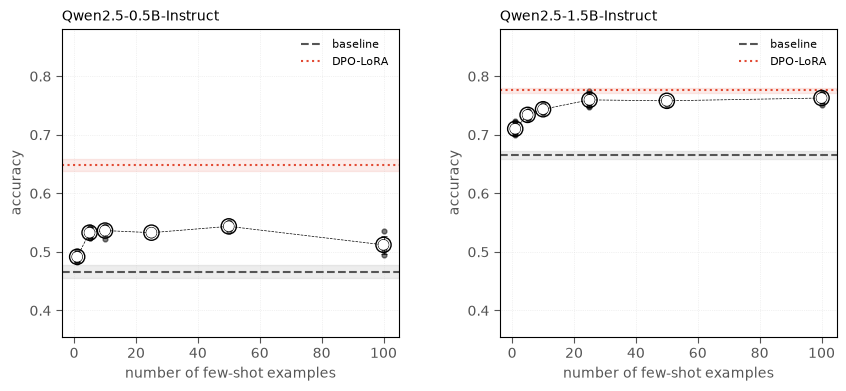

In [15]:
accuracy_values = pd.concat([
    summary["accuracy_mean"] - summary["accuracy_std"],
    summary["accuracy_mean"] + summary["accuracy_std"],
    runs["accuracy"],
])
accuracy_lim = (max(0.0, accuracy_values.min() - 0.1), min(1.0, accuracy_values.max() + 0.1))

figure_dir = SAVE_DIR / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

n_models = len(model_order)
fig = plt.figure(figsize=(5.0 * n_models, 4.0))
grid = gridspec.GridSpec(1, n_models, wspace=0.3)
for i, model in enumerate(model_order):
    swept = arm(model, "few_shot_sweep").sort_values("k_positive")
    plot_sensitivity(
        swept,
        metric="accuracy",
        sweep_col="k_positive",
        compare_to_pipelines=refs_for(model),
        per_trial_data=runs[runs["model"] == model],
        ax=fig.add_subplot(grid[0, i]),
        metric_label="accuracy",
        sweep_label="number of few-shot examples",
        title=model,
        ylim=accuracy_lim,
    )
fig.savefig(figure_dir / "sensitivity_accuracy.png", bbox_inches="tight", dpi=150)
plt.show()

### Accuracy vs positional bias tradeoff

We then examine the tradeoff between accuracy and positional bias. The few-shot configurations are colored by `k_positive`, the baseline is drawn as a black X marker and DPO-LoRA as a red square, and the Pareto frontier marks the configurations that are not dominated by any other (higher accuracy is better, lower positional bias is better). The axis limits are shared across panels.

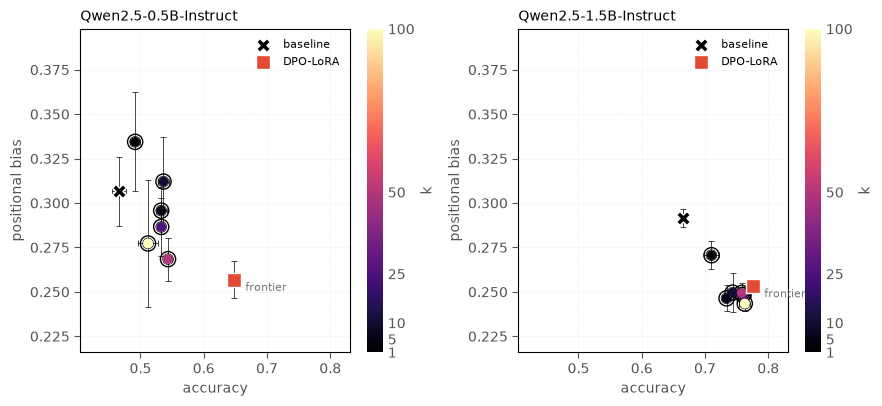

In [16]:
bias_values = pd.concat([
    summary["positional_bias_mean"] - summary["positional_bias_std"],
    summary["positional_bias_mean"] + summary["positional_bias_std"],
    runs["positional_bias"],
])
x_lim = (max(0.0, accuracy_values.min() - 0.05), min(1.0, accuracy_values.max() + 0.05))
y_lim = (max(0.0, bias_values.min() - 0.02), bias_values.max() + 0.02)

fig = plt.figure(figsize=(5.0 * n_models, 4.2))
grid = gridspec.GridSpec(1, n_models, wspace=0.3)
for i, model in enumerate(model_order):
    swept = arm(model, "few_shot_sweep").sort_values("k_positive")
    plot_tradeoff(
        swept,
        x_metric="accuracy",
        y_metric="positional_bias",
        sweep_col="k_positive",
        compare_to_pipelines=refs_for(model),
        ax=fig.add_subplot(grid[0, i]),
        x_label="accuracy",
        y_label="positional bias",
        sweep_label="k",
        title=model,
        show_pareto=True,
        maximize_x=True,
        maximize_y=False,
        xlim=x_lim,
        ylim=y_lim,
    )
fig.savefig(figure_dir / "tradeoff.png", bbox_inches="tight", dpi=150)
plt.show()

### Summary table

The table below lists every configuration, sorted by model, pipeline, and number of examples, and is also written to `summary.csv` next to the figures.

In [17]:
summary = summary.sort_values(["model", "pipeline", "k_positive"], ignore_index=True)
summary.to_csv(figure_dir / "summary.csv", index=False)
summary.round(3)

,model,pipeline,config_id,accuracy_mean,accuracy_std,accuracy_sem,positional_bias_mean,positional_bias_std,positional_bias_sem,n_trials,k_positive
0,Qwen2.5-0.5B-Instruct,baseline,baseline,0.466,0.011,0.005,0.306,0.020,0.009,5,NaN
1,Qwen2.5-0.5B-Instruct,dpo_lora,53d2e0f9f30e,0.648,0.011,0.005,0.257,0.010,0.005,5,NaN
2,Qwen2.5-0.5B-Instruct,few_shot_sweep,462374057c43,0.492,0.008,0.004,0.334,0.028,0.012,5,1.0
3,Qwen2.5-0.5B-Instruct,few_shot_sweep,fa9ee0733170,0.533,0.009,0.004,0.296,0.013,0.006,5,5.0
4,Qwen2.5-0.5B-Instruct,few_shot_sweep,a1dd8953ee3e,0.536,0.009,0.004,0.312,0.025,0.011,5,10.0
5,Qwen2.5-0.5B-Instruct,few_shot_sweep,2fd7496ff9a4,0.533,0.003,0.001,0.287,0.016,0.007,5,25.0
6,Qwen2.5-0.5B-Instruct,few_shot_sweep,36682d3d0fe5,0.544,0.006,0.003,0.268,0.012,0.005,5,50.0
7,Qwen2.5-0.5B-Instruct,few_shot_sweep,1339f6150d5f,0.512,0.015,0.007,0.277,0.036,0.016,5,100.0
8,Qwen2.5-1.5B-Instruct,baseline,baseline,0.665,0.007,0.003,0.292,0.005,0.002,5,NaN
9,Qwen2.5-1.5B-Instruct,dpo_lora,ea105f9d8699,0.776,0.005,0.002,0.253,0.003,0.001,5,NaN


## Takeaways

This notebook compared few-shot prompting to a DPO-trained LoRA adapter on the commonsense MCQA task, with the unsteered model as a reference, measuring accuracy and positional bias under deterministic choice shuffling. The few-shot sweep shows how accuracy scales with the number of in-context examples relative to the fine-tuned and baseline arms, and the tradeoff panel shows how positional bias moves alongside accuracy across both models.